In [26]:
#import required libraries
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

In [27]:
#read railway.csv file
df=pd.read_csv(r"C:\Users\Hoda-Mostafa\Downloads\railway.csv")

In [28]:
#to replace each space in columns names with (_) 
df.columns = df.columns.str.replace(" ", "_")

In [29]:
df

,Transaction_ID,Date_of_Purchase,Time_of_Purchase,Purchase_Type,Payment_Method,Railcard,Ticket_Class,Ticket_Type,Price,Departure_Station,Arrival_Destination,Date_of_Journey,Departure_Time,Arrival_Time,Actual_Arrival_Time,Journey_Status,Reason_for_Delay,Refund_Request
0,da8a6ba8-b3dc-4677-b176,12/8/2023,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,1/1/2024,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,12/16/2023,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,1/1/2024,9:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,12/19/2023,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,1/2/2024,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,12/20/2023,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,1/1/2024,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,12/27/2023,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,1/1/2024,16:45:00,19:00:00,19:00:00,On Time,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31648,1304623d-b8b7-4999-8e9c,4/30/2024,18:42:58,Online,Credit Card,NaN,Standard,Off-Peak,4,Manchester Piccadilly,Liverpool Lime Street,4/30/2024,20:00:00,20:30:00,20:30:00,On Time,NaN,No
31649,7da22246-f480-417c-bc2f,4/30/2024,18:46:10,Online,Contactless,NaN,Standard,Off-Peak,10,London Euston,Birmingham New Street,4/30/2024,20:15:00,21:35:00,21:35:00,On Time,NaN,No
31650,add9debf-46c1-4c75-b52d,4/30/2024,18:56:41,Station,Credit Card,NaN,Standard,Off-Peak,4,Manchester Piccadilly,Liverpool Lime Street,4/30/2024,20:15:00,20:45:00,20:45:00,On Time,NaN,No
31651,b92b047c-21fd-4859-966a,4/30/2024,19:51:47,Station,Credit Card,NaN,Standard,Off-Peak,10,London Euston,Birmingham New Street,4/30/2024,21:15:00,22:35:00,22:35:00,On Time,NaN,No


# Cleaning

In [30]:
df.isnull().sum()

Transaction_ID             0
Date_of_Purchase           0
Time_of_Purchase           0
Purchase_Type              0
Payment_Method             0
Railcard               20918
Ticket_Class               0
Ticket_Type                0
Price                      0
Departure_Station          0
Arrival_Destination        0
Date_of_Journey            0
Departure_Time             0
Arrival_Time               0
Actual_Arrival_Time     1880
Journey_Status             0
Reason_for_Delay       27481
Refund_Request             0
dtype: int64

In [31]:
#to provide a summary of the DataFrame 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Transaction_ID       31653 non-null  object
 1   Date_of_Purchase     31653 non-null  object
 2   Time_of_Purchase     31653 non-null  object
 3   Purchase_Type        31653 non-null  object
 4   Payment_Method       31653 non-null  object
 5   Railcard             10735 non-null  object
 6   Ticket_Class         31653 non-null  object
 7   Ticket_Type          31653 non-null  object
 8   Price                31653 non-null  int64 
 9   Departure_Station    31653 non-null  object
 10  Arrival_Destination  31653 non-null  object
 11  Date_of_Journey      31653 non-null  object
 12  Departure_Time       31653 non-null  object
 13  Arrival_Time         31653 non-null  object
 14  Actual_Arrival_Time  29773 non-null  object
 15  Journey_Status       31653 non-null  object
 16  Reas

In [32]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
31648    False
31649    False
31650    False
31651    False
31652    False
Length: 31653, dtype: bool

In [33]:
#to generate summary statistics for the numerical columns in the DataFrame. 
df.describe()

,Price
count,31653.000000
mean,23.439200
std,29.997628
min,1.000000
25%,5.000000
50%,11.000000
75%,35.000000
max,267.000000


In [34]:
q1 = df['Price'].quantile(0.25)
q3 = df['Price'].quantile(0.75)
IQR = q3 - q1 

lower_bound = q1 - 1.5*IQR
upper_bound = q3 + 1.5*IQR

print(lower_bound)
print(upper_bound)

-40.0
80.0


In [35]:
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

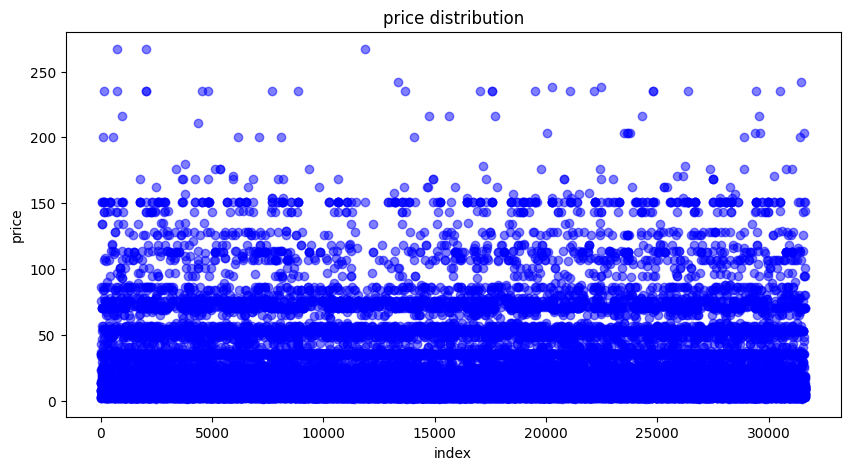

In [36]:
plt.figure(figsize=(10,5))
plt.scatter(df.index , df['Price'], alpha = 0.5 , color = 'blue')
plt.xlabel('index')
plt.ylabel('price')
plt.title('price distribution')

plt.show()

In [37]:
df['Reason_for_Delay'].unique()

array([nan, 'Signal Failure', 'Technical Issue', 'Weather Conditions',
       'Weather', 'Staffing', 'Staff Shortage', 'Signal failure',
       'Traffic'], dtype=object)

In [38]:
#to replace 'Staff Shortage' with 'Staffing' and 'Weather' with 'Weather Conditions' in the 'Reason_for_Delay' column
df['Reason_for_Delay']= df['Reason_for_Delay'].replace({'Staffing':'Staff Shortage','Weather':'Weather Conditions'})

In [39]:
#capitalizing the first letter of each value in 'Reason_for_Delay' column.
df["Reason_for_Delay"] = df["Reason_for_Delay"].astype(str).apply(lambda x: x.title())

In [40]:
df['Departure_Station'].unique()

array(['London Paddington', 'London Kings Cross', 'Liverpool Lime Street',
       'London Euston', 'York', 'Manchester Piccadilly',
       'Birmingham New Street', 'London St Pancras', 'Oxford', 'Reading',
       'Edinburgh Waverley', 'Bristol Temple Meads'], dtype=object)

In [41]:
#to replace occurrences of "Edinburgh" in the 'Departure_Station' column with "Edinburgh Waverley"
df['Departure_Station']= df['Departure_Station'].replace({'Edinburgh':'Edinburgh Waverley'})

In [42]:
df['Arrival_Destination'].unique()

array(['Liverpool Lime Street', 'York', 'Manchester Piccadilly',
       'Reading', 'London Euston', 'Oxford', 'Durham',
       'London St Pancras', 'Birmingham New Street', 'London Paddington',
       'Bristol Temple Meads', 'Tamworth', 'London Waterloo', 'Sheffield',
       'Wolverhampton', 'Leeds', 'Stafford', 'Doncaster', 'Swindon',
       'Nottingham', 'Peterborough', 'Edinburgh', 'Crewe',
       'London Kings Cross', 'Leicester', 'Nuneaton', 'Didcot',
       'Edinburgh Waverley', 'Coventry', 'Wakefield', 'Cardiff Central',
       'Warrington'], dtype=object)

In [43]:
#replaces occurrences of "Edinburgh" in the 'Arrival_Destination' column with "Edinburgh Waverley"
df['Arrival_Destination']= df['Arrival_Destination'].replace({'Edinburgh':'Edinburgh Waverley'})

In [44]:
#to fill nuls values in 'Railcard' column with (No Railcard)
df['Railcard'] = df['Railcard'].fillna('No Railcard')

## Pre-Processing 

In [45]:
#to convert all datetime columns to datetime data type
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%m/%d/%Y')  
df['Date_of_Purchase'] = pd.to_datetime(df['Date_of_Purchase'], format='%m/%d/%Y') 

In [46]:
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'], format='%H:%M:%S') 
df['Actual_Arrival_Time'] = pd.to_datetime(df['Actual_Arrival_Time'], format='%H:%M:%S')
df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], format='%H:%M:%S')
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], format='%H:%M:%S')

In [47]:
#to extract only the time and convert values to time without date
df['Arrival_Time']= df['Arrival_Time'].dt.time
df['Actual_Arrival_Time']= df['Actual_Arrival_Time'].dt.time
df['Departure_Time']= df['Departure_Time'].dt.time
df['Time_of_Purchase']= df['Time_of_Purchase'].dt.time

In [48]:
#to get all stations 
All_Stations = pd.concat([df['Departure_Station'], df['Arrival_Destination']], ignore_index=True).unique()

In [49]:
All_Stations

array(['London Paddington', 'London Kings Cross', 'Liverpool Lime Street',
       'London Euston', 'York', 'Manchester Piccadilly',
       'Birmingham New Street', 'London St Pancras', 'Oxford', 'Reading',
       'Edinburgh Waverley', 'Bristol Temple Meads', 'Durham', 'Tamworth',
       'London Waterloo', 'Sheffield', 'Wolverhampton', 'Leeds',
       'Stafford', 'Doncaster', 'Swindon', 'Nottingham', 'Peterborough',
       'Crewe', 'Leicester', 'Nuneaton', 'Didcot', 'Coventry',
       'Wakefield', 'Cardiff Central', 'Warrington'], dtype=object)

In [50]:
#create "Station" Dtatframe with column named 'Station_Name' 
Station =pd.DataFrame({'Station_Name': All_Stations})

In [51]:
Station

,Station_Name
0,London Paddington
1,London Kings Cross
2,Liverpool Lime Street
3,London Euston
4,York
5,Manchester Piccadilly
6,Birmingham New Street
7,London St Pancras
8,Oxford
9,Reading


In [52]:
#This code creates a dictionary called station_codes that maps station names to their unique station codes
station_codes = {
    "London Paddington": "PAD","London Kings Cross": "KGX",
    "Liverpool Lime Street": "LIV","London Euston": "EUS","York": "YRK",
    "Manchester Piccadilly": "MAN","Birmingham New Street": "BHM","London St Pancras": "STP",
    "Oxford": "OXF","Reading": "RDG","Edinburgh Waverley": "EDB",
    "Bristol Temple Meads": "BRI","Durham": "DHM","Tamworth": "TAM","London Waterloo": "WAT",
    "Sheffield": "SHF","Wolverhampton": "WVH",
    "Leeds": "LDS","Stafford": "STA","Doncaster": "DON","Swindon": "SWI", "Nottingham": "NOT",
    "Peterborough": "PBO","Crewe": "CRE","Leicester": "LEI","Nuneaton": "NUN","Didcot": "DID","Coventry": "COV",
    "Wakefield": "WKF","Cardiff Central": "CDF","Warrington": "WAC"}

In [53]:
#It assigns values to the Station_Code column in the Station DataFrame
Station['Station_Code']= Station['Station_Name'].map(station_codes)

In [54]:
# to retrieve the unique values from the 'Station_Code' column in the Station DataFrame.
Station['Station_Code'].unique()

array(['PAD', 'KGX', 'LIV', 'EUS', 'YRK', 'MAN', 'BHM', 'STP', 'OXF',
       'RDG', 'EDB', 'BRI', 'DHM', 'TAM', 'WAT', 'SHF', 'WVH', 'LDS',
       'STA', 'DON', 'SWI', 'NOT', 'PBO', 'CRE', 'LEI', 'NUN', 'DID',
       'COV', 'WKF', 'CDF', 'WAC'], dtype=object)

In [55]:
#drop duplicates to get the unique stations
Station= Station.drop_duplicates()

In [56]:
#rearrange "Stations" columns
Station = Station[['Station_Code', 'Station_Name']]

In [57]:
#Here is a DataFrame named "Stations" which we will treat as a table
Station

,Station_Code,Station_Name
0,PAD,London Paddington
1,KGX,London Kings Cross
2,LIV,Liverpool Lime Street
3,EUS,London Euston
4,YRK,York
5,MAN,Manchester Piccadilly
6,BHM,Birmingham New Street
7,STP,London St Pancras
8,OXF,Oxford
9,RDG,Reading


In [58]:
#drop duplicates to get the unique routes
Routes = df[['Departure_Station', 'Arrival_Destination']].drop_duplicates().reset_index(drop=True)

In [59]:
#This code assigns station codes to the 'Departure_Station_Code' and 'Arrival_Destination_Code' columns 
#in the Routes DataFrame by mapping values from a dictionary called station_codes.
Routes["Departure_Station_Code"] = Routes["Departure_Station"].map(station_codes)
Routes["Arrival_Destination_Code"] = Routes["Arrival_Destination"].map(station_codes)

In [60]:
#This code creates the 'Route_Code' column in the Routes DataFrame by concatenating the 'Departure_Station_Code' and 
#'Arrival_Destination_Code' columns,separated by a hyphen ('-')
Routes ['Route_Code'] = Routes ['Departure_Station_Code'].str.cat(Routes ['Arrival_Destination_Code'], sep='-')

In [61]:
Routes ['Route_Code'] 

0     PAD-LIV
1     KGX-YRK
2     LIV-MAN
3     PAD-RDG
4     LIV-EUS
       ...   
59    YRK-WKF
60    YRK-LIV
61    BRI-CDF
62    LIV-BHM
63    MAN-WAC
Name: Route_Code, Length: 64, dtype: object

In [62]:
#Here is a DataFrame named "Routes" which we will treat as a table
Routes

,Departure_Station,Arrival_Destination,Departure_Station_Code,Arrival_Destination_Code,Route_Code
0,London Paddington,Liverpool Lime Street,PAD,LIV,PAD-LIV
1,London Kings Cross,York,KGX,YRK,KGX-YRK
2,Liverpool Lime Street,Manchester Piccadilly,LIV,MAN,LIV-MAN
3,London Paddington,Reading,PAD,RDG,PAD-RDG
4,Liverpool Lime Street,London Euston,LIV,EUS,LIV-EUS
...,...,...,...,...,...
59,York,Wakefield,YRK,WKF,YRK-WKF
60,York,Liverpool Lime Street,YRK,LIV,YRK-LIV
61,Bristol Temple Meads,Cardiff Central,BRI,CDF,BRI-CDF
62,Liverpool Lime Street,Birmingham New Street,LIV,BHM,LIV-BHM


In [63]:
#create "Journeys" dataframe 
Journeys = df[['Departure_Station', 'Arrival_Destination' , 'Date_of_Journey' , 'Departure_Time' ,'Arrival_Time',
               'Actual_Arrival_Time','Journey_Status','Reason_for_Delay']]

In [64]:
#This code merges the Journeys DataFrame with the Routes DataFrame to add 
#the 'Route_Code' based on matching departure and arrival stations
Journeys = Journeys.merge(Routes[['Departure_Station', 'Arrival_Destination','Route_Code']], 
              on=['Departure_Station', 'Arrival_Destination'], 
              how='left')

In [65]:
Journeys['Date_of_Journey']

0       2024-01-01
1       2024-01-01
2       2024-01-02
3       2024-01-01
4       2024-01-01
           ...    
31648   2024-04-30
31649   2024-04-30
31650   2024-04-30
31651   2024-04-30
31652   2024-04-30
Name: Date_of_Journey, Length: 31653, dtype: datetime64[ns]

In [66]:
#add 'Journey_ID' column to "Journeys" , This code creates a new 'Journey_ID' column in the Journeys DataFrame
#by concatenating the 'Route_Code', 'Date_of_Journey', and 'Departure_Time' columns.
Journeys['Journey_ID'] = Journeys['Route_Code'].astype(str).str.cat(
    [Journeys['Date_of_Journey'].astype(str), Journeys['Departure_Time'].astype(str)], sep=':')

In [67]:
df['Date_of_Journey'] 

0       2024-01-01
1       2024-01-01
2       2024-01-02
3       2024-01-01
4       2024-01-01
           ...    
31648   2024-04-30
31649   2024-04-30
31650   2024-04-30
31651   2024-04-30
31652   2024-04-30
Name: Date_of_Journey, Length: 31653, dtype: datetime64[ns]

In [68]:
#Here is a DataFrame named "Journeys" which we will treat as a table.
Journeys

,Departure_Station,Arrival_Destination,Date_of_Journey,Departure_Time,Arrival_Time,Actual_Arrival_Time,Journey_Status,Reason_for_Delay,Route_Code,Journey_ID
0,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,Nan,PAD-LIV,PAD-LIV:2024-01-01:11:00:00
1,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,KGX-YRK,KGX-YRK:2024-01-01:09:45:00
2,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,Nan,LIV-MAN,LIV-MAN:2024-01-02:18:15:00
3,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,Nan,PAD-RDG,PAD-RDG:2024-01-01:21:30:00
4,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,Nan,LIV-EUS,LIV-EUS:2024-01-01:16:45:00
...,...,...,...,...,...,...,...,...,...,...
31648,Manchester Piccadilly,Liverpool Lime Street,2024-04-30,20:00:00,20:30:00,20:30:00,On Time,Nan,MAN-LIV,MAN-LIV:2024-04-30:20:00:00
31649,London Euston,Birmingham New Street,2024-04-30,20:15:00,21:35:00,21:35:00,On Time,Nan,EUS-BHM,EUS-BHM:2024-04-30:20:15:00
31650,Manchester Piccadilly,Liverpool Lime Street,2024-04-30,20:15:00,20:45:00,20:45:00,On Time,Nan,MAN-LIV,MAN-LIV:2024-04-30:20:15:00
31651,London Euston,Birmingham New Street,2024-04-30,21:15:00,22:35:00,22:35:00,On Time,Nan,EUS-BHM,EUS-BHM:2024-04-30:21:15:00


In [69]:
#rearrange "Journeys" columns
Journeys = Journeys[['Journey_ID','Route_Code','Date_of_Journey','Departure_Time','Arrival_Time','Actual_Arrival_Time',
                     'Journey_Status','Reason_for_Delay']]

In [70]:
#create dataframe "Transactions"
Transactions = df[['Transaction_ID','Date_of_Purchase', 'Time_of_Purchase', 'Purchase_Type',
                   'Payment_Method','Railcard','Ticket_Class','Ticket_Type','Price','Departure_Station','Arrival_Destination','Refund_Request']]

In [71]:
#add 'Journey_ID' column to "Transactions"
Transactions['Journey_ID'] = Journeys['Journey_ID'].values

C:\Users\Hoda-Mostafa\AppData\Local\Temp\ipykernel_3608\3888611291.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Transactions['Journey_ID'] = Journeys['Journey_ID'].values


In [72]:
#rearrange "Transactions" columns
Transactions = Transactions[['Transaction_ID','Journey_ID','Date_of_Purchase', 'Time_of_Purchase', 'Purchase_Type','Payment_Method',
                             'Railcard','Ticket_Class','Ticket_Type','Price','Refund_Request']]

In [73]:
#Here is a DataFrame named "Transactions" which we will treat as a table
Transactions 

,Transaction_ID,Journey_ID,Date_of_Purchase,Time_of_Purchase,Purchase_Type,Payment_Method,Railcard,Ticket_Class,Ticket_Type,Price,Refund_Request
0,da8a6ba8-b3dc-4677-b176,PAD-LIV:2024-01-01:11:00:00,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,No
1,b0cdd1b0-f214-4197-be53,KGX-YRK:2024-01-01:09:45:00,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,No
2,f3ba7a96-f713-40d9-9629,LIV-MAN:2024-01-02:18:15:00,2023-12-19,19:51:27,Online,Credit Card,No Railcard,Standard,Advance,3,No
3,b2471f11-4fe7-4c87-8ab4,PAD-RDG:2024-01-01:21:30:00,2023-12-20,23:00:36,Station,Credit Card,No Railcard,Standard,Advance,13,No
4,2be00b45-0762-485e-a7a3,LIV-EUS:2024-01-01:16:45:00,2023-12-27,18:22:56,Online,Contactless,No Railcard,Standard,Advance,76,No
...,...,...,...,...,...,...,...,...,...,...,...
31648,1304623d-b8b7-4999-8e9c,MAN-LIV:2024-04-30:20:00:00,2024-04-30,18:42:58,Online,Credit Card,No Railcard,Standard,Off-Peak,4,No
31649,7da22246-f480-417c-bc2f,EUS-BHM:2024-04-30:20:15:00,2024-04-30,18:46:10,Online,Contactless,No Railcard,Standard,Off-Peak,10,No
31650,add9debf-46c1-4c75-b52d,MAN-LIV:2024-04-30:20:15:00,2024-04-30,18:56:41,Station,Credit Card,No Railcard,Standard,Off-Peak,4,No
31651,b92b047c-21fd-4859-966a,EUS-BHM:2024-04-30:21:15:00,2024-04-30,19:51:47,Station,Credit Card,No Railcard,Standard,Off-Peak,10,No


In [74]:
#save Transactions as csv
Transactions.to_csv("D:\\Documents\\Transactions.csv",index= False)

In [75]:
#save Station as csv
Station.to_csv("D:\\Documents\\Station.csv",index= False)

In [76]:
#drop 'Departure_Station', 'Arrival_Destination' columns
#Routes = Routes.drop(columns=['Departure_Station', 'Arrival_Destination'])

In [77]:
#rarrange "Routes" columns
Routes = Routes[['Route_Code','Departure_Station_Code','Arrival_Destination_Code']]

In [78]:
#save Routes as cvs
Routes.to_csv("D:\\Documents\\Routes.csv",index= False)

In [79]:
#deop 'Departure_Station', 'Arrival_Destination' columns
#Journeys = Journeys.drop(columns=['Departure_Station', 'Arrival_Destination'])

In [80]:
#drop duplicates to get unique Journeys
Journeys = Journeys.drop_duplicates()

In [81]:
Journeys

,Journey_ID,Route_Code,Date_of_Journey,Departure_Time,Arrival_Time,Actual_Arrival_Time,Journey_Status,Reason_for_Delay
0,PAD-LIV:2024-01-01:11:00:00,PAD-LIV,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,Nan
1,KGX-YRK:2024-01-01:09:45:00,KGX-YRK,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure
2,LIV-MAN:2024-01-02:18:15:00,LIV-MAN,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,Nan
3,PAD-RDG:2024-01-01:21:30:00,PAD-RDG,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,Nan
4,LIV-EUS:2024-01-01:16:45:00,LIV-EUS,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,Nan
...,...,...,...,...,...,...,...,...
31648,MAN-LIV:2024-04-30:20:00:00,MAN-LIV,2024-04-30,20:00:00,20:30:00,20:30:00,On Time,Nan
31649,EUS-BHM:2024-04-30:20:15:00,EUS-BHM,2024-04-30,20:15:00,21:35:00,21:35:00,On Time,Nan
31650,MAN-LIV:2024-04-30:20:15:00,MAN-LIV,2024-04-30,20:15:00,20:45:00,20:45:00,On Time,Nan
31651,EUS-BHM:2024-04-30:21:15:00,EUS-BHM,2024-04-30,21:15:00,22:35:00,22:35:00,On Time,Nan


In [62]:
#save Journeys as cvs
Journeys.to_csv("D:\\Documents\\Journeys.csv",index= False)

In [63]:
#read BankHolidays.csv file
holidays = pd.read_csv(r"C:\Users\Hoda-Mostafa\Downloads\BankHolidays.csv")

In [64]:
holidays

,Date,Day of the week,Bank holiday
0,2023-12-25,Monday,Christmas Day
1,2023-12-26,Tuesday,Boxing Day
2,2024-01-01,Monday,New Year’s Day
3,2024-03-29,Friday,Good Friday
4,2024-04-01,Monday,Easter Monday
5,2024-05-06,Monday,Early May bank holiday
6,2024-05-27,Monday,Spring bank holiday
7,2024-08-26,Monday,Summer bank holiday
8,2024-12-25,Wednesday,Christmas Day
9,2024-12-26,Thursday,Boxing Day


In [65]:
holidays = holidays.rename(columns={"Bank holiday": "Bank_holiday"})

In [66]:
# Drop the Day of the week column
holidays = holidays.drop('Day of the week', axis=1)

In [67]:
# Ensure the Date column is in datetime format
holidays['Date'] = pd.to_datetime(holidays['Date'])

In [68]:
# Define the date range for the calendar table
start_date = pd.to_datetime("2023-12-01")
end_date = pd.to_datetime("2024-05-31")

In [69]:
# Create a date range
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

In [70]:
# Create a DataFrame calender
calendar = pd.DataFrame(date_range, columns=['Date'])

In [71]:
# Add columns
calendar['Year'] = calendar['Date'].dt.year
calendar['Quarter'] = calendar['Date'].dt.quarter
calendar['Month_Number'] = calendar['Date'].dt.month
calendar['Month_Name'] = calendar['Date'].dt.month_name().str[:3]   # Short month name
calendar['Week_Number'] = calendar['Date'].dt.isocalendar().week
calendar['Day_of_Week'] = calendar['Date'].dt.day_name().str[:3]  # Short day name
calendar['Day_Type'] = calendar['Date'].apply( lambda x: 'Weekend' if x.weekday() >= 5 else 'Workday')

In [72]:
# Merge with the holidays DataFrame to add Holiday Name
calendar = pd.merge(calendar, holidays, how='left', left_on='Date', right_on='Date')

In [73]:
# Update Day Type for holidays
calendar['Day_Type'] = calendar.apply(
    lambda row: 'Holiday' if pd.notna(row['Bank_holiday']) else row['Day_Type'], axis=1)

In [74]:
# Rename the Bank holiday column to Holiday Name
calendar = calendar.rename(columns={"Bank_holiday": "Holiday_Name"})
#calendar = calendar.rename(columns={"Bank_holiday": "Holiday_Name"})

In [ ]:
calendar.head()

In [76]:
# Save to CSV
calendar.to_csv('D:\\Documents\\Calendar.csv', index=False)

  # Analysis Questions

### 1-	What is the number of Tickets sold?

In [77]:
#Counts the total number of transactions (tickets)
number_of_Tickets = Transactions['Transaction_ID'].count()

#display result
print(f"The Number of Tickets is: {number_of_Tickets}")

The Number of Tickets is: 31653


### 2-What is the most common Payment Method?

In [78]:
#Calculates the number of unique transactions for each payment method
commom_payment_method = Transactions.groupby('Payment_Method')['Transaction_ID'].nunique()
#Converts the result into a DataFrame
commom_payment_method = commom_payment_method.reset_index(name = 'Number of Tickets')
#Sorts the payment methods by the number of transactions in descending order
commom_payment_method = commom_payment_method.sort_values(by = 'Number of Tickets' , ascending = False)

commom_payment_method 

,Payment_Method,Number of Tickets
1,Credit Card,19136
0,Contactless,10834
2,Debit Card,1683


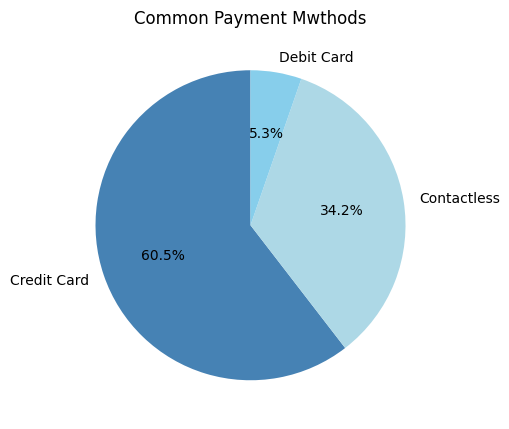

In [79]:
#answer Visualization
plt.figure(figsize=(5,6))
plt.pie(commom_payment_method['Number of Tickets'] , labels= commom_payment_method['Payment_Method'] , autopct='%1.1f%%', 
        colors=['SteelBlue','lightblue','skyblue'], startangle=90)
plt.title('Common Payment Mwthods')

plt.show()

### 3-What is the most common Ticket Type and Ticket Class? 

In [80]:
#Calculates the number of unique transactions for each ticket type
commom_Ticket_Type = Transactions.groupby('Ticket_Type')['Transaction_ID'].nunique()
#Converts the result into a DataFrame
commom_Ticket_Type = commom_Ticket_Type.reset_index(name= 'Number of Tickets')
#Sorts the ticket types by the number of tickets in descending order
commom_Ticket_Type = commom_Ticket_Type.sort_values(by = 'Number of Tickets' , ascending = False)

commom_Ticket_Type

,Ticket_Type,Number of Tickets
0,Advance,17561
2,Off-Peak,8752
1,Anytime,5340


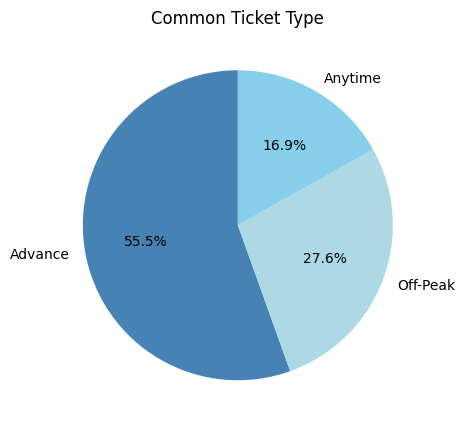

In [81]:
#answer Visualization
plt.figure(figsize=(5,6))
plt.pie(commom_Ticket_Type['Number of Tickets'] , labels= commom_Ticket_Type['Ticket_Type'] , autopct='%1.1f%%', 
        colors=['SteelBlue','lightblue','skyblue'], startangle=90)
plt.title('Common Ticket Type')

plt.show()

In [82]:
#Calculates the number of unique transactions for each ticket class
commom_Ticket_Class = Transactions.groupby('Ticket_Class')['Transaction_ID'].nunique()
#Converts the result into a DataFrame
commom_Ticket_Class = commom_Ticket_Class.reset_index(name = 'Number of Tickets')
#Sorts the ticket class by the number of tickets in descending order
commom_Ticket_Calss = commom_Ticket_Class.sort_values(by = 'Number of Tickets' , ascending = False)

commom_Ticket_Class

,Ticket_Class,Number of Tickets
0,First Class,3058
1,Standard,28595


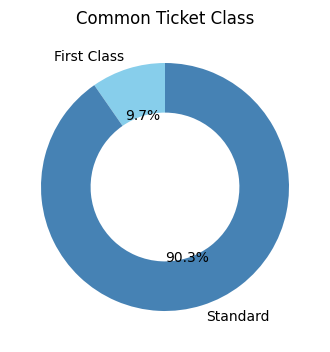

In [83]:
#answer Visualization
plt.figure(figsize=(4, 5))
wedges, texts, autotexts = plt.pie(
    commom_Ticket_Class['Number of Tickets'],
    labels=commom_Ticket_Class['Ticket_Class'],
    autopct='%1.1f%%',
    colors=['SkyBlue', 'Steelblue'],
    startangle=90,
    wedgeprops=dict(width=0.4))
plt.title('Common Ticket Class')
plt.show()

### 4-	How are the Tickets distributed by hours  ? 

In [84]:
# merge Transctions & Journeys Dataframes
Transaction_Journey= Transactions.merge(Journeys, on='Journey_ID', how='left')

#Get Day Hours from 'Departure_Time' column
Transaction_Journey['Hour_12'] = Transaction_Journey['Departure_Time'].apply(lambda x: x.strftime('%I %p'))

# to Get the Arrived Journeys
actual_journeys = Transaction_Journey[Transaction_Journey['Journey_Status'] != "Cancelled"]

# To get the number tickets per Hour
Hour_counts = actual_journeys.groupby("Hour_12")['Transaction_ID'].count()

# To get The number of tickets per AM Hour
am_counts = Hour_counts[Hour_counts.index.str.endswith('AM')]
# To get The number of tickets per pm Hour
pm_counts = Hour_counts[Hour_counts.index.str.endswith('PM')]


In [85]:
am_counts

Hour_12
01 AM     621
02 AM     878
03 AM     532
04 AM     995
05 AM     703
06 AM    2925
07 AM    2541
08 AM    2031
09 AM    1185
10 AM     508
11 AM    1087
12 AM     804
Name: Transaction_ID, dtype: int64

In [86]:
pm_counts

Hour_12
01 PM    1213
02 PM     813
03 PM    1129
04 PM    2197
05 PM    2709
06 PM    2802
07 PM     426
08 PM    1022
09 PM     554
10 PM     762
11 PM     609
12 PM     727
Name: Transaction_ID, dtype: int64

In [87]:
#to get the most Busiest pm Hours
top_3_am = am_counts.nlargest(3)

#to get the most Busiest pm Hours
top_3_pm = pm_counts.nlargest(3)

print("Top 3 busiest AM hours:\n", top_3_am)
print("\nTop 3 busiest PM hours:\n", top_3_pm)

Top 3 busiest AM hours:
 Hour_12
06 AM    2925
07 AM    2541
08 AM    2031
Name: Transaction_ID, dtype: int64

Top 3 busiest PM hours:
 Hour_12
06 PM    2802
05 PM    2709
04 PM    2197
Name: Transaction_ID, dtype: int64


# The Peak AM Hours 6-8 AM and The Peak PM Hours 4-6 PM

In [88]:
#convert the Departure_Time cloumn into datetime format with hours, minutes, and seconds
actual_journeys['Departure_Time'] = pd.to_datetime(actual_journeys['Departure_Time'], format='%H:%M:%S')
#Converts the 'Departure_Time' column to a 12-hour format with AM/PM
actual_journeys['Departure_Time_12'] = actual_journeys['Departure_Time'].dt.strftime('%I:%M %p')
#Calculates the count of transactions for each unique departure time (in 12-hour format)
Travel_Time_counts = actual_journeys.groupby("Departure_Time_12")['Transaction_ID'].count()

#Filters the 'Travel_Time_counts' to separate the counts of transactions into two categories: 'am , pm'
am_counts = Travel_Time_counts[Travel_Time_counts.index.str.endswith('AM')]
pm_counts = Travel_Time_counts[Travel_Time_counts.index.str.endswith('PM')]

#to get the departure times with the most transactions for both AM and PM.
top_1_am = am_counts.nlargest(1)
top_1_pm = pm_counts.nlargest(1)

print(f"The most busiest AM Travel Time is : {top_1_am}")
print(f"The most busiest PM Travel Time is : {top_1_pm}")

C:\Users\Hoda-Mostafa\AppData\Local\Temp\ipykernel_19932\1395155080.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_journeys['Departure_Time'] = pd.to_datetime(actual_journeys['Departure_Time'], format='%H:%M:%S')


The most busiest AM Travel Time is : Departure_Time_12
06:30 AM    1337
Name: Transaction_ID, dtype: int64
The most busiest PM Travel Time is : Departure_Time_12
06:45 PM    2300
Name: Transaction_ID, dtype: int64


C:\Users\Hoda-Mostafa\AppData\Local\Temp\ipykernel_19932\1395155080.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_journeys['Departure_Time_12'] = actual_journeys['Departure_Time'].dt.strftime('%I:%M %p')


# The most busiest AM Travel Time is 6:30 AM 
# The most busiest PM Travel Time is 6:45 AM

### 5-What percentage of customers use railcard? 

In [89]:
#Calculates the count of transactions for each railcard type and rounds the result to two decimal places.
railcard_used= Transactions.groupby('Railcard')['Railcard'].count().round(2)
#calculate the percent of total 
Railcard_Usage_Percentage=(railcard_used/Transactions['Railcard'].count()*100).round(2)

Railcard_Usage_Percentage_df = Railcard_Usage_Percentage.reset_index(name = 'Percentage_railcard_used')

Railcard_Usage_Percentage_df

,Railcard,Percentage_railcard_used
0,Adult,15.31
1,Disabled,9.76
2,No Railcard,66.09
3,Senior,8.85


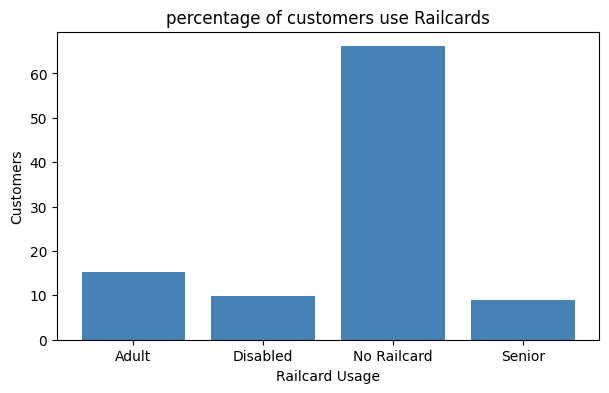

In [90]:
#answer Visualization
plt.figure(figsize=(7,4))
plt.bar(Railcard_Usage_Percentage_df['Railcard'],Railcard_Usage_Percentage_df['Percentage_railcard_used'],color='steelblue')
plt.xlabel('Railcard Usage')
plt.ylabel('Customers')
plt.title('percentage of customers use Railcards')

plt.show()

### 6-What is the Number of online Transactions vs station Transactions? 

In [91]:
#Calculates the number of unique transactions for each purchase type
online_vs_station = Transactions.groupby('Purchase_Type')['Transaction_ID'].nunique()
#Converts the result into a DataFrame
online_vs_station = online_vs_station.reset_index(name = 'Number of Tickets')
##Sorts purchase types (online vs. station) by the number of tickets in descending order
online_vs_station = online_vs_station.sort_values(by = 'Number of Tickets' , ascending = False)

online_vs_station

,Purchase_Type,Number of Tickets
0,Online,18521
1,Station,13132


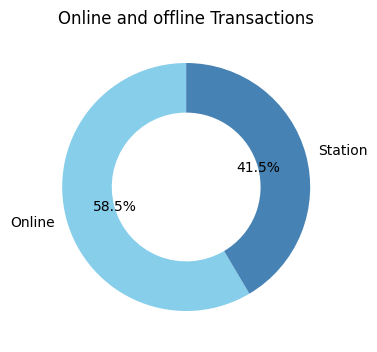

In [92]:
plt.figure(figsize=(4, 5))
wedges, texts, autotexts = plt.pie(
    online_vs_station['Number of Tickets'],
    labels=online_vs_station['Purchase_Type'],
    autopct='%1.1f%%',
    colors=['SkyBlue', 'Steelblue'],
    startangle=90,
    wedgeprops=dict(width=0.4))
plt.title('Online and offline Transactions')
plt.show()

### 7-What is the number of Tickets per Month?

In [93]:
#generate  purchase months from Date_of_Purchase column
Transactions['purchase_month'] = Transactions['Date_of_Purchase'].dt.month_name()
#calculate the number of tickets per month
number_of_tickets_per_month = Transactions.groupby('purchase_month')['Transaction_ID'].count()

number_of_tickets_per_month_df = number_of_tickets_per_month.reset_index(name = 'number of Tickets')
number_of_tickets_per_month_df

,purchase_month,number of Tickets
0,April,7748
1,December,34
2,February,7337
3,January,8434
4,March,8100


### 8- What is the average number of soled tickets per day type

In [95]:
#Merges transactions with calendar data based on the purchase date.
transactions_calendar = Transactions.merge(calendar, left_on = 'Date_of_Purchase', right_on = 'Date', how = 'left')

#Calculates the average number of tickets sold per day for each day type.
avg_tickets_per_daytype = (transactions_calendar.groupby('Day_Type')['Transaction_ID'].nunique()/transactions_calendar.groupby('Day_Type')
                           ['Date'].nunique()).round()

#Converts the average tickets per day type into a DataFrame with a readable column name.
avg_tickets_per_daytype_df = avg_tickets_per_daytype.reset_index(name = 'Average_Tickets')

#Sorts the average tickets per day type in descending order to show the most active day types first
avg_tickets_per_daytype_df= avg_tickets_per_daytype_df.sort_values(by = 'Average_Tickets', ascending = False)
#print the result
avg_tickets_per_daytype_df 

,Day_Type,Average_Tickets
2,Workday,251.0
1,Weekend,247.0
0,Holiday,131.0


# Railway Performance
### 1-What is the total number of Journeys?


In [96]:
#Counts the total number of journeys by counting the values in the 'Journey_ID' column.
Total_journeys = Journeys['Journey_ID'].count()
#display result
print(f" The Total Number of Journeys Is: {Total_journeys}")

 The Total Number of Journeys Is: 19871


### 2-What is the total number of Journeys On Time?

In [97]:
#Filters the Journeys dataset to include only journeys with a status of 'On Time'
on_time_journeys = Journeys[Journeys['Journey_Status'] == 'On Time']
#Counts the number of journeys that were completed on time
number_of_on_time_journeys = on_time_journeys['Journey_ID'].count()

print(f" The Total Number of On Time Journeys Is: {number_of_on_time_journeys}")

 The Total Number of On Time Journeys Is: 18019


### 3- How many journeys are delayed

In [98]:
#Filters the Journeys dataset to include only journeys with a status of 'Delayed'
delayed_journeys = Journeys[Journeys['Journey_Status'] == 'Delayed']
#Counts the number of delayed journeys
number_of_delayed_journeys = delayed_journeys['Journey_ID'].count()

print(f" The Total Number of Delayed Journeys Is: {number_of_delayed_journeys}")

 The Total Number of Delayed Journeys Is: 1062


### 4-How many journeys are cancelled?

In [99]:
#Filters the Journeys dataset to include only journeys with a status of 'Canceeled'
cancelled_journeys = Journeys[Journeys['Journey_Status'] == 'Cancelled']
#Counts the number of Canceeled journeys
number_of_cancelled_journeys = cancelled_journeys['Journey_ID'].count()

print(f" The Total Number of Cancelled Journeys Is: {number_of_cancelled_journeys}")

 The Total Number of Cancelled Journeys Is: 790


### 5-How is Journeys distributed by months?

In [100]:
#Extracts the month name from the 'Date_of_Journey' column
Journeys['journeys_month'] = Journeys['Date_of_Journey'].dt.month_name() 
#Calculates the total number of journeys for each month
total_journeys_per_month = Journeys.groupby('journeys_month')['Journey_ID'].count()

total_journeys_per_month

journeys_month
April       4889
February    4839
January     5060
March       5083
Name: Journey_ID, dtype: int64

### 6- What is the number of Journeys per Day?

In [101]:
#Extracts the day name from the 'Date_of_Journey' column
Journeys['Journeys_Day'] = Journeys['Date_of_Journey'].dt.day_name() 
#Calculates the total number of journeys for each day of the week
total_journeys_per_day = Journeys.groupby('Journeys_Day')['Journey_ID'].count()

total_journeys_per_day

Journeys_Day
Friday       2729
Monday       2804
Saturday     2803
Sunday       2853
Thursday     2892
Tuesday      2900
Wednesday    2890
Name: Journey_ID, dtype: int64

### 7- How were journeys distributed by delay reasons

In [102]:
#Calculates the number of journeys delayed for each specific reason
journeys_by_delay_reasons = Journeys.groupby('Reason_for_Delay')['Journey_ID'].count()

journeys_by_delay_reasons = journeys_by_delay_reasons.reset_index()

journeys_by_delay_reasons.dropna()

journeys_by_delay_reasons

,Reason_for_Delay,Journey_ID
0,Nan,18019
1,Signal Failure,424
2,Staff Shortage,437
3,Technical Issue,373
4,Traffic,152
5,Weather Conditions,466


### 8-	How many Transactions are cancelled and delayed ? and what is the percentage of them?

In [103]:
#Filters the 'Transaction_Journey' dataset to include only transactions where the journey status is 'Cancelled'
cancelled_Transactions = Transaction_Journey[Transaction_Journey['Journey_Status'] == 'Cancelled']

#Calculates the number of unique transactions where the journey status is 'Cancelled'
cancelled_counts = cancelled_Transactions['Transaction_ID'].nunique()

cancelled_counts

1880

In [104]:
#Filters the 'Transaction_Journey' dataset to include only transactions where the journey status is 'Delayed'
delayed_Transactions = Transaction_Journey[Transaction_Journey['Journey_Status'] == 'Delayed']

#Calculates the number of unique transactions where the journey status is 'Delayed'
delayed_counts = delayed_Transactions['Transaction_ID'].nunique()

delayed_counts

2292

In [105]:
#Filters the 'cancelled_Transactions' dataset to include only transactions where a refund request was made
cancelled_refunded = cancelled_Transactions[cancelled_Transactions['Refund_Request'] == 'Yes']

#Calculates the number of unique transactions with a refund request
cancelled_refunded_count = cancelled_refunded['Transaction_ID'].nunique()

print(f"The number of Passengers requested refund on Cancelled Journeys: {cancelled_refunded_count}")

The number of Passengers requested refund on Cancelled Journeys: 572


In [106]:
#Filters the 'delayed_Transactions' dataset to include only transactions where a refund request was made for delayed journeys
delayed_rfunded = delayed_Transactions[delayed_Transactions['Refund_Request'] == 'Yes']

#Calculates the number of unique transactions with a refund request
delayed_refunded_count = delayed_rfunded['Transaction_ID'].nunique()

print(f"The number of Passengers requested refund on delayed Journeys:{delayed_refunded_count}")

The number of Passengers requested refund on delayed Journeys:546


### 9-What is the average delay duration?

In [107]:
#Converts the 'Arrival_Time' , 'Actual_Arrival_Time' columns in the 'Journeys' DataFrame to a datetime
Journeys['Arrival_Time'] = pd.to_datetime(Journeys['Arrival_Time'], format='%H:%M:%S') 
Journeys['Actual_Arrival_Time'] = pd.to_datetime(Journeys['Actual_Arrival_Time'], format='%H:%M:%S')

#Filters the 'Journeys' dataset to include only journeys with a status of 'Delayed'
delayed_journeys = Journeys[Journeys['Journey_Status'] == 'Delayed']
#Calculates the delay duration for each delayed journey by subtracting the scheduled 'Arrival_Time' from the 'Actual_Arrival_Time'
delayed_journeys['delay_duration'] = delayed_journeys['Actual_Arrival_Time'] - delayed_journeys['Arrival_Time']

#Calculates the average delay duration
average_delay = delayed_journeys['delay_duration'].mean()
#Converts the average delay duration into total seconds by using the total_seconds() method
total_seconds = int(average_delay.total_seconds())

#to get hours and minutes
hours = total_seconds // 3600
minutes = (total_seconds % 3600) // 60
seconds = total_seconds % 60

#Formats the total delay duration (in hours, minutes, and seconds) into a string with the format 'HH:MM:SS'
formatted_time = f"{hours:02d}:{minutes:02d}:{seconds:02d}"

print("Average Delay Duration :", formatted_time)

Average Delay Duration : 00:37:43


C:\Users\Hoda-Mostafa\AppData\Local\Temp\ipykernel_19932\3216368686.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delayed_journeys['delay_duration'] = delayed_journeys['Actual_Arrival_Time'] - delayed_journeys['Arrival_Time']


### 10- On Time Journeys per month

In [108]:
#Filters the Journeys dataset to include only journeys with a status of 'On Time'
on_time_journeys = Journeys[Journeys['Journey_Status'] == 'On Time']

#Extracts the month name from the 'Date_of_Journey' column
on_time_journeys['journeys_month'] = on_time_journeys['Date_of_Journey'].dt.month_name() 

#Calculates the number of on time journeys for each month
on_time_journeys_per_month = on_time_journeys.groupby('journeys_month')['Journey_ID'].count()

on_time_journeys_per_month_df = on_time_journeys_per_month.reset_index(name = 'Number of On Time Journeys')
on_time_journeys_per_month_df                                                                       

C:\Users\Hoda-Mostafa\AppData\Local\Temp\ipykernel_19932\1841896244.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  on_time_journeys['journeys_month'] = on_time_journeys['Date_of_Journey'].dt.month_name()


,journeys_month,Number of On Time Journeys
0,April,4456
1,February,4402
2,January,4587
3,March,4574


### Reliability Score for On Time Journeys

In [109]:
#Filters the Journeys dataset to include only journeys with a status of 'On Time'
on_time_journeys = Journeys[Journeys['Journey_Status'] == 'On Time']

#Calculates the percentage of on time journeys for each month
percentage_on_time_journeys_per_month = ((on_time_journeys.groupby('journeys_month')
['Journey_ID'].count()/Journeys.groupby('journeys_month')['Journey_ID'].count())*100).round(2)

percentage_on_time_journeys_per_month_df = percentage_on_time_journeys_per_month.reset_index(name = 'Percentage of On Time Journeys')

percentage_on_time_journeys_per_month_df 

,journeys_month,Percentage of On Time Journeys
0,April,91.14
1,February,90.97
2,January,90.65
3,March,89.99


### AVG Journeys per Day Type

In [110]:
#Merges transactions with calendar data based on the purchase date.
journeys_calendar = Journeys.merge(calendar, left_on = 'Date_of_Journey', right_on = 'Date', how = 'left')

#Calculates the average number of tickets sold per day for each day type.
avg_journeys_per_daytype = (journeys_calendar.groupby('Day_Type')['Journey_ID'].nunique()/journeys_calendar.groupby('Day_Type')
                           ['Date'].nunique()).round(1)

#Converts the average tickets per day type into a DataFrame with a readable column name.
avg_journeys_per_daytype_df = avg_journeys_per_daytype.reset_index(name = 'Average_journeys')

#Sorts the average tickets per day type in descending order to show the most active day types first
avg_journeys_per_daytype_df= avg_journeys_per_daytype_df.sort_values(by = 'Average_journeys', ascending = False)
#print the result
avg_journeys_per_daytype_df 

,Day_Type,Average_journeys
1,Weekend,166.4
2,Workday,165.8
0,Holiday,96.3


# Routes & Stations Analysis
### 1-What is the Total number of Routes ? 


In [111]:
#Counts the total number of routes by counting the 'Route_Code' values
number_of_routes = Routes['Route_Code'].count()

print("The Total Number of Routes is:" ,number_of_routes)

The Total Number of Routes is: 64


### 2-What is the number of Departure and Arrival Stations ?

In [112]:
#Calculates the number of unique departure stations
departure_stations_count = Routes['Departure_Station_Code'].nunique()

print(f"The Number Of Departure Stations is : {departure_stations_count} Stations")

The Number Of Departure Stations is : 12 Stations


In [113]:
#Calculates the number of unique arrival stations
arrival_stations_count = Routes['Arrival_Destination_Code'].nunique()

print(f"The Number Of Arrival Stations is : {arrival_stations_count} Stations")

The Number Of Arrival Stations is : 31 Stations


### 3-What is the top 5 of used Departure and Arrival Stations ?

In [114]:
#Merges the 'Journeys' and 'Routes' datasets on the 'Route_Code' column
journey_routes = Journeys.merge(Routes , on= 'Route_Code' , how= 'left')
#Merges the 'journey_routes' dataset with the 'Station' dataset on the 'Departure_Station_Code' from 'journey_routes' and 'Station_Code' from 'Station'
journey_routes_sataion = journey_routes.merge(Station , left_on = 'Departure_Station_Code', right_on = 'Station_Code', how= 'left')

#Groups the 'journey_routes_sataion' dataset by 'Departure_Station_Code' and 'Station_Name'
departure_station = journey_routes_sataion.groupby(['Departure_Station_Code','Station_Name'])['Journey_ID'].nunique()
departure_station_df = departure_station.reset_index(name='Number_of_Journeys')

#sort values based on Number_of_Arrival column
departure_station_df = departure_station_df.sort_values(by= 'Number_of_Journeys', ascending= False)
#display the Top 5 departure Stations
Top_5_departure_stations = departure_station_df.head()
Top_5_departure_stations

,Departure_Station_Code,Station_Name,Number_of_Journeys
6,MAN,Manchester Piccadilly,3521
3,EUS,London Euston,3059
5,LIV,Liverpool Lime Street,2997
8,PAD,London Paddington,2643
4,KGX,London Kings Cross,2625


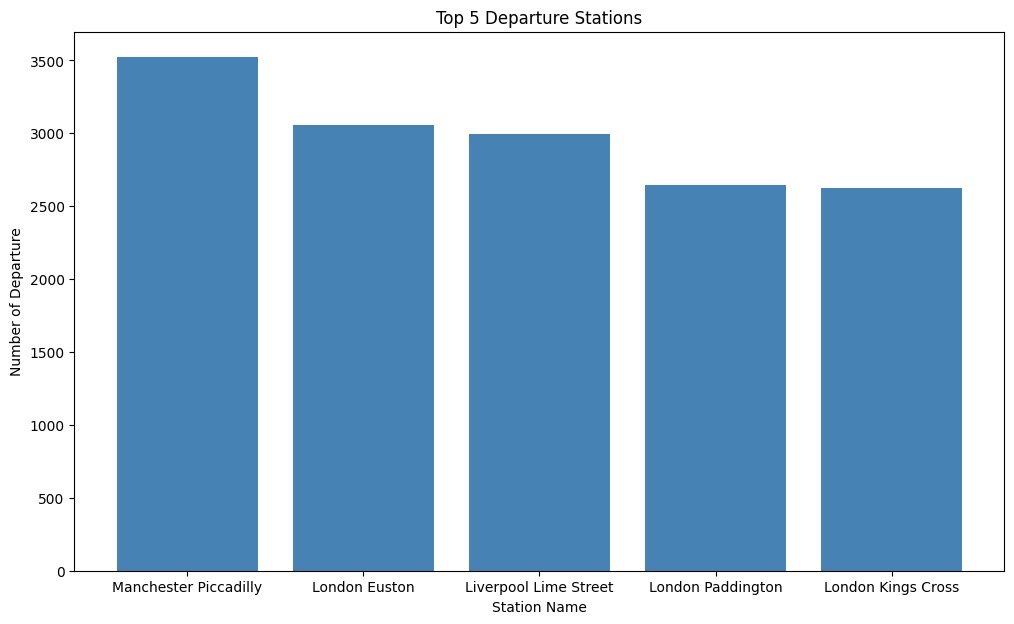

In [115]:
#answer as visual
plt.figure(figsize=(12,7))
plt.bar(Top_5_departure_stations['Station_Name'],Top_5_departure_stations['Number_of_Journeys'],
        color='steelblue')
plt.xlabel('Station Name')
plt.ylabel('Number of Departure')
plt.title('Top 5 Departure Stations')

plt.show()

In [116]:
#Merges the 'Journeys' and 'Routes' datasets on the 'Route_Code' column
journey_routes = Journeys.merge(Routes , on= 'Route_Code' , how= 'left')
#Merges the 'journey_routes' with the 'Station' datasets on the 'Arrival_Destination_Code' from 'journey_routes' and 'Station_Code' from 'Station'
journey_routes_sataion = journey_routes.merge(Station , left_on = 'Arrival_Destination_Code', right_on = 'Station_Code', how= 'left')
#Groups the 'journey_routes_sataion' dataset by 'Arrival_Destination_Code' and 'Station_Name'
arrival_stations = journey_routes_sataion.groupby(['Arrival_Destination_Code','Station_Name'])['Journey_ID'].nunique()

arrival_stations_df = arrival_stations.reset_index(name='Number_of_Journeys')

#sort values based on Number_of_Arrival column
arrival_stations_df =arrival_stations_df.sort_values(by= 'Number_of_Journeys', ascending= False)

#display the Top 5 arrival Stations
Top_5_arrival_stations = arrival_stations_df.head()
Top_5_arrival_stations

,Arrival_Destination_Code,Station_Name,Number_of_Journeys
0,BHM,Birmingham New Street,4680
13,LIV,Liverpool Lime Street,3042
14,MAN,Manchester Piccadilly,2946
30,YRK,York,2480
20,RDG,Reading,2457


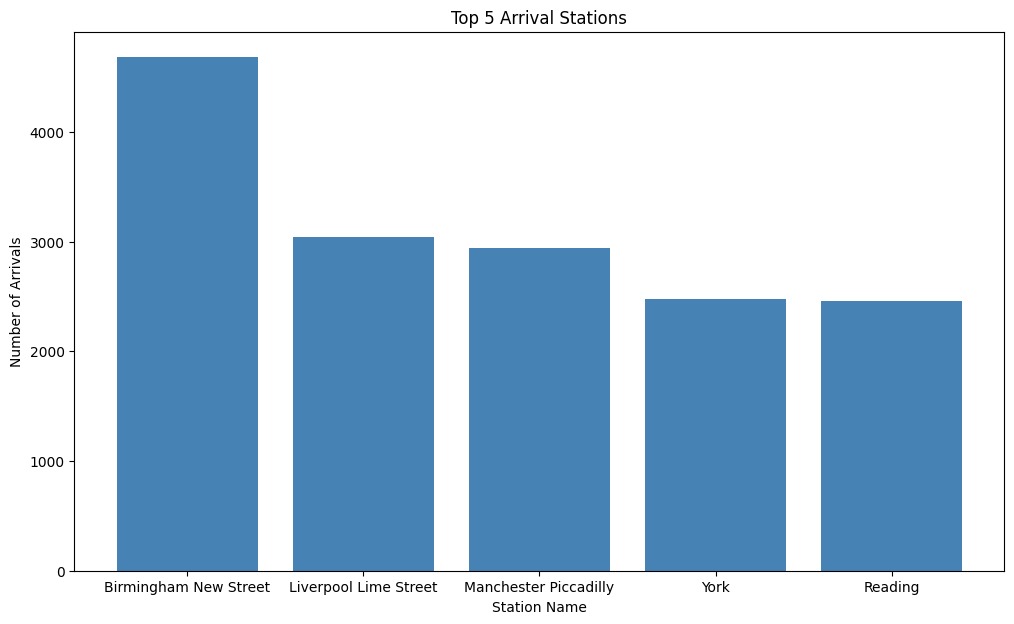

In [117]:
#answer as visual
plt.figure(figsize=(12,7))
plt.bar(Top_5_arrival_stations['Station_Name'],Top_5_arrival_stations['Number_of_Journeys'],
        color='steelblue')
plt.xlabel('Station Name')
plt.ylabel('Number of Arrivals')
plt.title('Top 5 Arrival Stations')

plt.show()

### 4-What are the top 5 routes with number of journeys ?

In [118]:
#Calculate the number of journeys for each route
total_journeys_per_route = Journeys.groupby("Route_Code")["Journey_ID"].count()
#Resets the index of the 'total_journeys_per_route' grouped data and creates a new DataFrame
total_journeys_per_route = total_journeys_per_route.reset_index(name='Number_of_Journeys')
#Sorts the 'total_journeys_per_route' DataFrame by the 'Number_of_Journeys'
total_journeys_per_route = total_journeys_per_route.sort_values(by ='Number_of_Journeys' , ascending = False)

top_5_Routes_with_journeys = total_journeys_per_route.head()

top_5_Routes_with_journeys

,Route_Code,Number_of_Journeys
34,MAN-LIV,2675
16,EUS-BHM,2515
45,PAD-RDG,2412
22,KGX-YRK,2400
27,LIV-MAN,2267


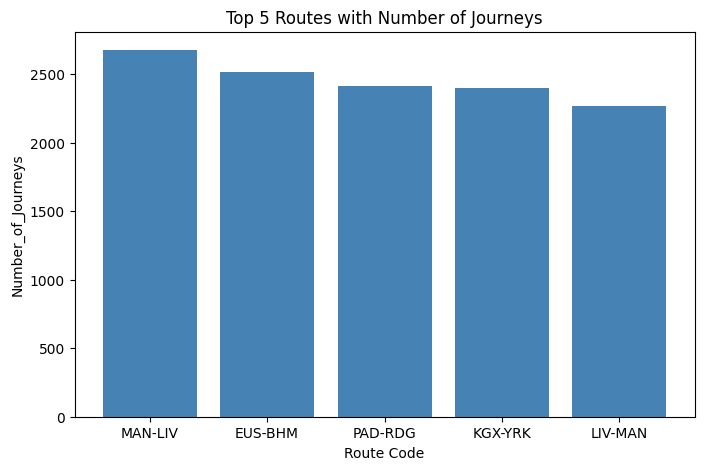

In [119]:
#answer as visual
plt.figure(figsize=(8,5))
plt.bar(top_5_Routes_with_journeys['Route_Code'],top_5_Routes_with_journeys['Number_of_Journeys'],
        color='steelblue')
plt.xlabel('Route Code')
plt.ylabel('Number_of_Journeys')
plt.title('Top 5 Routes with Number of Journeys')

plt.show()

### 5-What are the bottom 5 routes with number of journeys ?

In [120]:
bottom_5_Routes_with_journeys = total_journeys_per_route.tail()

bottom_5_Routes_with_journeys

,Route_Code,Number_of_Journeys
49,RDG-LIV,15
23,LIV-BHM,14
39,MAN-WAC,13
61,YRK-LIV,13
40,MAN-YRK,12


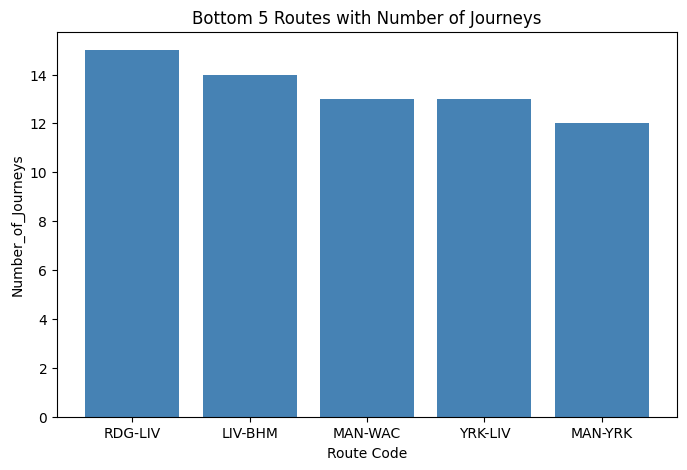

In [121]:
#answer as visual
plt.figure(figsize=(8,5))
plt.bar(bottom_5_Routes_with_journeys['Route_Code'],bottom_5_Routes_with_journeys['Number_of_Journeys'],
        color='steelblue')
plt.xlabel('Route Code')
plt.ylabel('Number_of_Journeys')
plt.title('Bottom 5 Routes with Number of Journeys')

plt.show()

### 6-What are the top 5 routes with highest percentage of delays?

In [122]:
#Calculate the number of journeys for each route
total_journeys_per_route = Journeys.groupby("Route_Code")["Journey_ID"].count()

# Calculate the number of delayed journeys for each route
delayed_journeys_per_route = Journeys[Journeys["Journey_Status"] == "Delayed"].groupby("Route_Code")["Journey_ID"].count()

# Calculate the delay percentage for each route
delay_percentage = (delayed_journeys_per_route / total_journeys_per_route) * 100

In [123]:
# Create a new DataFrame containing the percentages
delay_percentage_df = pd.DataFrame({"Total Journeys": total_journeys_per_route, 
                                    "Delayed Journeys": delayed_journeys_per_route, 
                                    "Delay Percentage": delay_percentage})

# Remove empty values (for routes that have no delays at all).
delay_percentage_df = delay_percentage_df.fillna(0)

# to Sort the routes based on the delay percentage in descending order
delay_percentage_df = delay_percentage_df.sort_values(by="Delay Percentage", ascending=False)

In [124]:
# to Display the top routes with the highest delay percentage
routes_with_highest_Percentage_Dalays= (delay_percentage_df.round()).head()

routes_with_highest_Percentage_Dalays

,Total Journeys,Delayed Journeys,Delay Percentage
Route_Code,,,
EDB-KGX,43,43.0,100.0
EUS-YRK,16,16.0,100.0
YRK-WKF,15,15.0,100.0
MAN-EUS,289,191.0,66.0
LIV-EUS,363,205.0,56.0


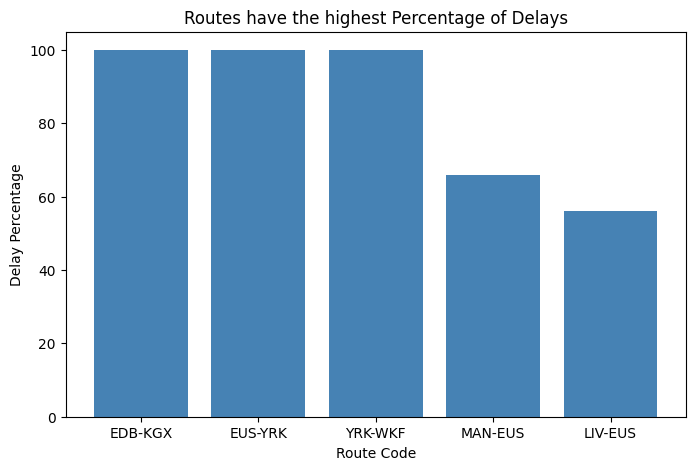

In [125]:
#answer Visualization
plt.figure(figsize=(8,5))
plt.bar(routes_with_highest_Percentage_Dalays.index, routes_with_highest_Percentage_Dalays['Delay Percentage'],color='steelblue')
plt.xlabel('Route Code')
plt.ylabel('Delay Percentage')
plt.title('Routes have the highest Percentage of Delays')

plt.show()

In [126]:
#Calculate the number of journeys for each route
total_journeys_per_route = Journeys.groupby("Route_Code")["Journey_ID"].count()

cancellation_journeys_per_route = Journeys[Journeys["Journey_Status"] == "Cancelled"].groupby("Route_Code")["Journey_ID"].count()

cancellation_percentage = (cancellation_journeys_per_route / total_journeys_per_route) * 100
# Create a new DataFrame containing the percentages
cancellation_percentage_df = pd.DataFrame({"Total Journeys": total_journeys_per_route, 
                                    "Cancelled Journeys": cancellation_journeys_per_route, 
                                    "cancellation Percentage": cancellation_percentage})

# Remove empty values (for routes that have no cancellations at all).
cancellation_percentage_df = cancellation_percentage_df.fillna(0)

cancellation_percentage_df = cancellation_percentage_df.sort_values(by="cancellation Percentage", ascending=False)

# to Display the top routes with the highest cancellation percentage
routes_with_highest_Percentage_cancellation = (cancellation_percentage_df.round()).head()

routes_with_highest_Percentage_cancellation 

,Total Journeys,Cancelled Journeys,cancellation Percentage
Route_Code,,,
LIV-BHM,14,2.0,14.0
RDG-DID,44,5.0,11.0
PAD-OXF,118,13.0,11.0
LIV-STP,29,3.0,10.0
BHM-PAD,30,3.0,10.0


# Sales & financial Analysis

### 1-Total Revenue and Net Revenue


In [127]:
#Calculates the total revenue by summing all values in the 'Price' column
total_revenue = Transactions['Price'].sum()

#display the result
print("Total Revenue :" ,total_revenue, "$")

Total Revenue : 741921 $


In [128]:
#Filters the Transactions dataset to include only transactions where no refund was requested
remain_transactions = Transactions[Transactions['Refund_Request'] == 'No']

#Calculates the net revenue by summing the prices of transactions without refund requests
net_revenue = remain_transactions['Price'].sum()

#display the result
print("The Net Revenue is:" , net_revenue,"$")

The Net Revenue is: 703219 $


### 2-What is the total refund?

In [129]:
#Filters the Transactions dataset to include only transactions where a refund was requested
refunded_transactions = Transactions[Transactions['Refund_Request'] == 'Yes']

#Calculates the total refund amount by summing the prices of refunded transactions
total_refund = refunded_transactions['Price'].sum()

#display the result
print("The total Refund is:" , total_refund,"$")

The total Refund is: 38702 $


### 3-What is the top and bottom 5 Net Revenue by Routes?

In [130]:
#Merges journey route details with non-refunded transactions based on Journey_ID
journey_routes_transactions = journey_routes.merge(remain_transactions, on = "Journey_ID" , how = 'left')
#Calculates the net revenue for each route by grouping the merged data by Route_Code and summing the prices
net_revenue_per_route = journey_routes_transactions.groupby('Route_Code')['Price'].sum()
#Converts the net revenue per route Series into a DataFrame and renames the revenue column to 'Net Revenue
net_revenue_per_route_df = net_revenue_per_route.reset_index(name= 'Net Revenue')
#sort_values descending by 'Net Revenue' 
net_revenue_per_route_df = net_revenue_per_route_df.sort_values(by = 'Net Revenue', ascending= False)
#get top five
top_net_revenue_per_route = net_revenue_per_route_df.head()
#display result
top_net_revenue_per_route

,Route_Code,Net Revenue
22,KGX-YRK,179498.0
25,LIV-EUS,100173.0
45,PAD-RDG,63841.0
17,EUS-MAN,59320.0
53,STP-BHM,52038.0


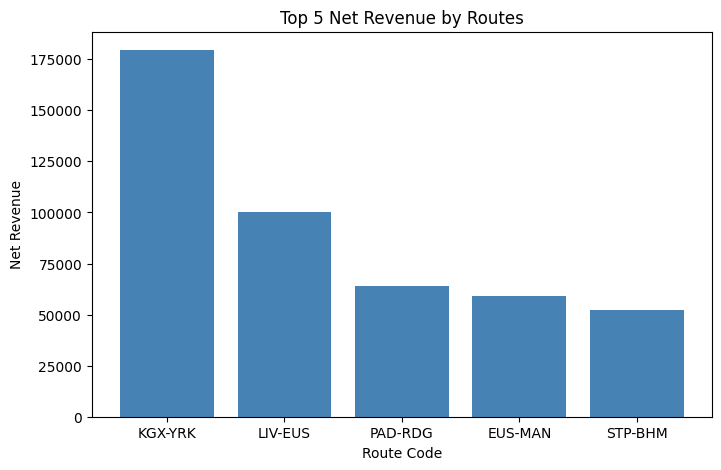

In [131]:
#answer Visualization
plt.figure(figsize=(8,5))
plt.bar(top_net_revenue_per_route['Route_Code'], top_net_revenue_per_route['Net Revenue'],color='steelblue')
plt.xlabel('Route Code')
plt.ylabel('Net Revenue')
plt.title('Top 5 Net Revenue by Routes')

plt.show()

In [132]:
#to get the bottom five revenue by routes
bottom_net_revenue_per_route = net_revenue_per_route_df.tail()
#display result
bottom_net_revenue_per_route

,Route_Code,Net Revenue
60,YRK-LDS,78.0
12,BHM-WVH,59.0
39,MAN-WAC,53.0
18,EUS-OXF,41.0
15,EDB-KGX,0.0


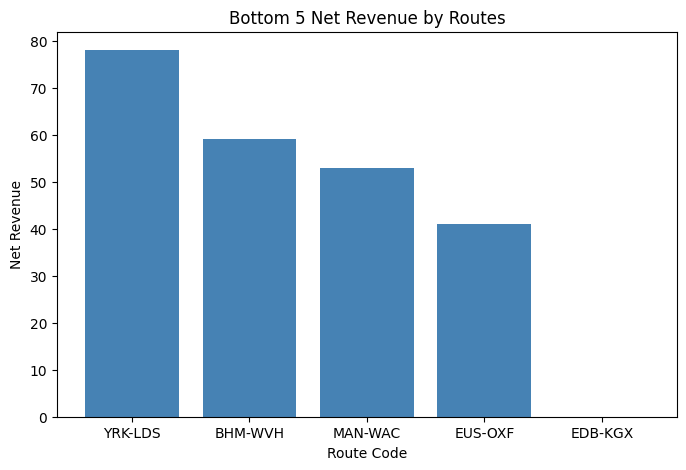

In [133]:
#answer Visualization
plt.figure(figsize=(8,5))
plt.bar(bottom_net_revenue_per_route['Route_Code'], bottom_net_revenue_per_route['Net Revenue'],color='steelblue')
plt.xlabel('Route Code')
plt.ylabel('Net Revenue')
plt.title('Bottom 5 Net Revenue by Routes')

plt.show()

### 4-What is the average ticket price?

In [134]:
avg_ticket_price = Transactions['Price'].mean().round(2)

print("The Avg. Ticket Price is:" , avg_ticket_price)

The Avg. Ticket Price is: 23.44


### 5-How is the net revenue distributed by payment method?

In [135]:
#Calculates the netrevenue for each payment method by grouping transactions and summing their prices
Revenue_per_payment_method = remain_transactions.groupby('Payment_Method')['Price'].sum()

Revenue_per_payment_method

Payment_Method
Contactless    214516
Credit Card    460480
Debit Card      28223
Name: Price, dtype: int64

In [136]:
#Calculates the percentage of net revenue contributed by each payment method and rounds the result
Revenue_distributed_by_payment_method = ((Revenue_per_payment_method/net_revenue)*100).round()

#display the result
Revenue_distributed_by_payment_method

Payment_Method
Contactless    31.0
Credit Card    65.0
Debit Card      4.0
Name: Price, dtype: float64

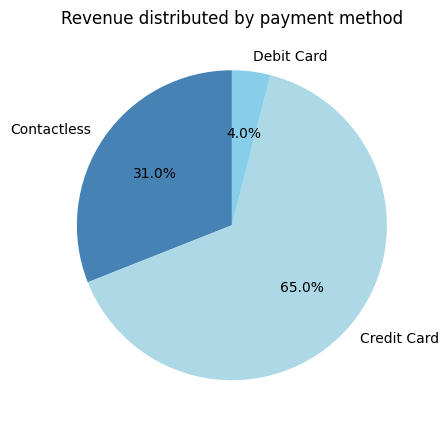

In [137]:
#answer Visualization
plt.figure(figsize=(5,6))
plt.pie(Revenue_distributed_by_payment_method.values , labels= Revenue_distributed_by_payment_method.index , autopct='%1.1f%%', 
        colors=['SteelBlue','lightblue','skyblue'], startangle=90)
plt.title('Revenue distributed by payment method')

plt.show()

### 6- How is the net revenue distributed by perchase Type?

In [138]:
#Calculates the net revenue for each purchase type by grouping transactions and summing their prices
Revenue_per_purchase_type = remain_transactions.groupby('Purchase_Type')['Price'].sum()
Revenue_per_purchase_type

Purchase_Type
Online     374540
Station    328679
Name: Price, dtype: int64

In [139]:
#Calculates the percentage of net revenue contributed by each purchase type and rounds the result
Revenue_distributed_by_purchase_type = ((Revenue_per_purchase_type/net_revenue)*100).round()

#display the result
Revenue_distributed_by_purchase_type

Purchase_Type
Online     53.0
Station    47.0
Name: Price, dtype: float64

### 7-How is the net revenue distributed by ticket type?

In [140]:
#Calculates the net revenue for each ticket type by grouping transactions and summing their prices
net_Revenue_per_ticket_type = remain_transactions.groupby('Ticket_Type')['Price'].sum()

net_Revenue_per_ticket_type 

Ticket_Type
Advance     293601
Anytime     200395
Off-Peak    209223
Name: Price, dtype: int64

In [141]:
#Calculates the percentage of net revenue contributed by each ticket type and rounds the result
Revenue_distributed_by_ticket_type = ((net_Revenue_per_ticket_type/net_revenue)*100).round()

#display the result
Revenue_distributed_by_ticket_type

Ticket_Type
Advance     42.0
Anytime     28.0
Off-Peak    30.0
Name: Price, dtype: float64

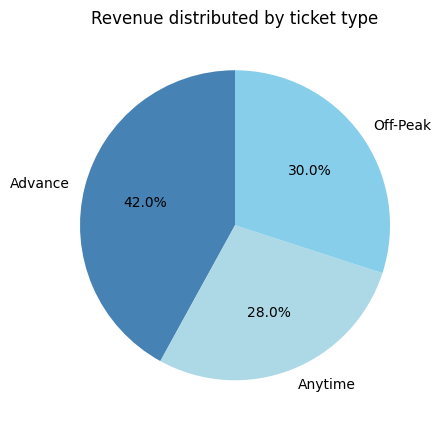

In [142]:
#answer Visualization
plt.figure(figsize=(5,6))
plt.pie(Revenue_distributed_by_ticket_type.values , labels= Revenue_distributed_by_ticket_type.index , autopct='%1.1f%%', 
        colors=['SteelBlue','lightblue','skyblue'], startangle=90)
plt.title('Revenue distributed by ticket type')

plt.show()

### 8-What is the monthly Trend of Net Revenue?

In [143]:
#Extracts the month name from each purchase date in the 'Date_of_Purchase' column
Transactions['purchase_month'] = Transactions['Date_of_Purchase'].dt.month_name()

#Filters transactions to include either those not made in December 
Filter_transactions = Transactions[Transactions['purchase_month'] != 'December']

#Filters the dataset to include only transactions where no refund was requested

net_transactions = Filter_transactions[Filter_transactions['Refund_Request'] != 'Yes']
#Calculates the monthly trend of net revenue by grouping non-refunded transactions
monthly_Trend_of_Net_Revenue = net_transactions.groupby('purchase_month')['Price'].sum()
#Converts the monthly net revenue Series into a DataFrame and renames the revenue column to 'net revenue'
monthly_Trend_of_Net_Revenue = monthly_Trend_of_Net_Revenue.reset_index(name = 'net revenue')

monthly_Trend_of_Net_Revenue                                                                        

,purchase_month,net revenue
0,April,177941
1,February,146432
2,January,193883
3,March,184312


### 9-What is the total refund by journey statues?

In [144]:
#Filters the Transactions dataset to include only transactions with a refund request
refunded_transactions = Transactions[Transactions['Refund_Request'] == 'Yes']

#Merges refunded transactions with journey details based on Journey_ID using a left join
refunded_transactions_journeys = refunded_transactions.merge(Journeys, on = 'Journey_ID' , how = 'left')

#Calculates the total refund amount for each journey status
refund_by_journey_status = refunded_transactions_journeys.groupby('Journey_Status')['Price'].sum()

#Converts the total refund amount by journey status into a DataFrame
refund_by_journey_status = refund_by_journey_status.reset_index(name = 'net_revenue')

refund_by_journey_status 

,Journey_Status,net_revenue
0,Cancelled,12537
1,Delayed,26165


### Net Revenue by Journey Status

In [205]:
#Merges the Transactions dataset with the Journeys dataset
transactions_journeys = Transactions.merge(Journeys, on = 'Journey_ID', how = 'left')

#Filters the transactions_journeys dataset to include only the transactions where the refund request is "No,"
net_transactions_journeys = transactions_journeys[transactions_journeys['Refund_Request'] == 'No']

#Calculates the total net revenue for each journey status
net_revenue_by_journey_status = net_transactions_journeys.groupby('Journey_Status')['Price'].sum()

net_revenue_by_journey_status_df = net_revenue_by_journey_status.reset_index(name= 'Net Revenue')

net_revenue_by_journey_status_df

,Journey_Status,Net Revenue
0,Cancelled,32919
1,Delayed,100649
2,On Time,569651
